**Capstone Project: Ad Click Prediction**

#Step 1 — Project Overview
*Problem Statement*
Predict whether a user will click on an advertisement or not using Machine Learning.

Objective

Build classification models:

Logistic Regression
Decision Tree
Random Forest

**Step 2 — Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Step 3 — Load Dataset**

Download dataset from:
https://www.kaggle.com/datasets/fayomi/advertising

In [2]:
df = pd.read_csv("ad_click_dataset.csv")
df.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


**Step 4 — Data Understanding**

In [3]:
df.shape

(10000, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  str    
 2   age               5234 non-null   float64
 3   gender            5307 non-null   str    
 4   device_type       8000 non-null   str    
 5   ad_position       8000 non-null   str    
 6   browsing_history  5218 non-null   str    
 7   time_of_day       8000 non-null   str    
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 703.3 KB


In [5]:
df.describe()

,id,age,click
count,10000.000000,5234.000000,10000.000000
mean,5060.211400,40.197363,0.650000
std,2861.758265,13.126420,0.476993
min,5.000000,18.000000,0.000000
25%,2529.000000,29.000000,0.000000
50%,5218.000000,39.500000,1.000000
75%,7466.000000,52.000000,1.000000
max,10000.000000,64.000000,1.000000


**Step 5 — Data Cleaning**

In [6]:
df.isnull().sum()

id                     0
full_name              0
age                 4766
gender              4693
device_type         2000
ad_position         2000
browsing_history    4782
time_of_day         2000
click                  0
dtype: int64

In [8]:
df.drop(['id','full_name'], axis=1, inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

df.head()

,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,NaN,Male,Desktop,Top,NaN,NaN,1
2,41.0,Non-Binary,NaN,Side,Education,Night,1
3,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [12]:
df.dtypes

age                 float64
gender                  str
device_type             str
ad_position             str
browsing_history        str
time_of_day             str
click                 int64
dtype: object

In [13]:
df = pd.get_dummies(df, drop_first=True)

**Step 6 — Exploratory Data Analysis (EDA)**

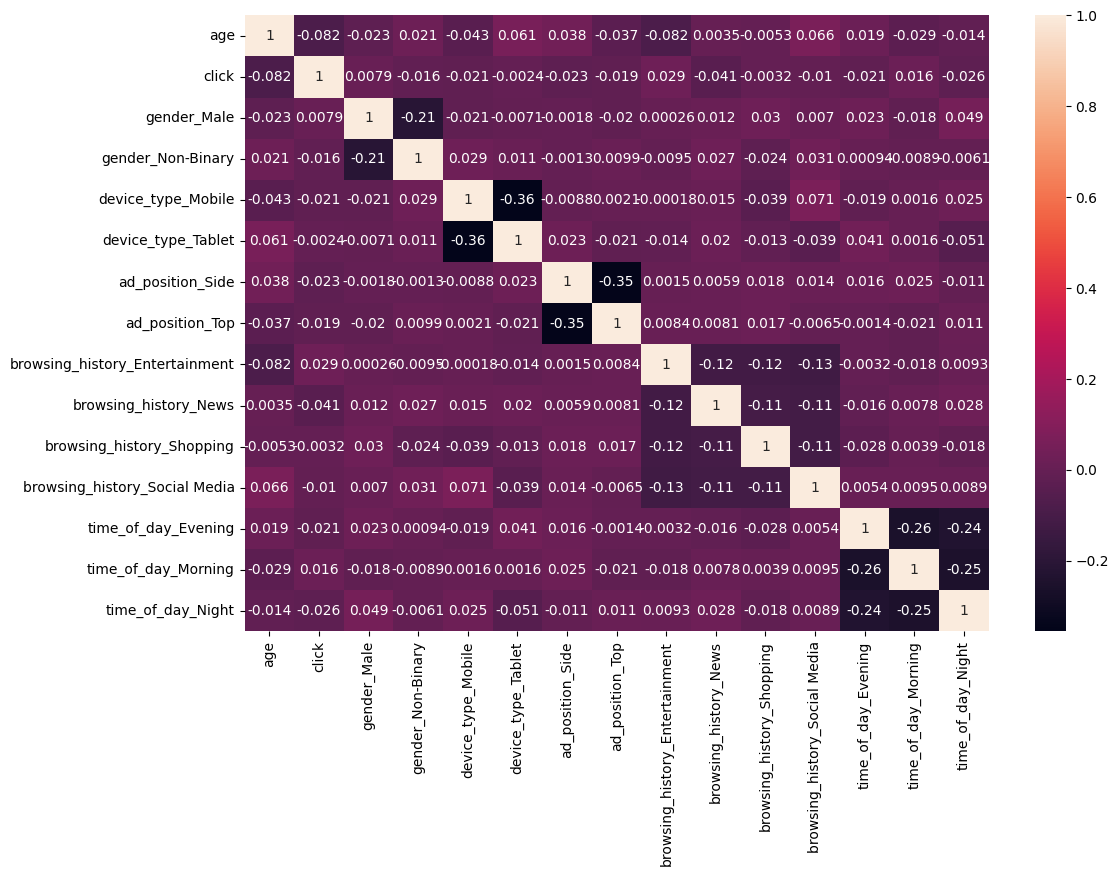

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

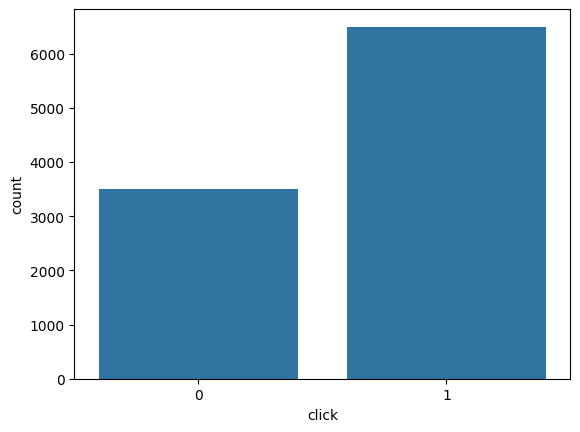

In [16]:
sns.countplot(x='click', data=df)
plt.show()

In [23]:
# Drop columns safely
df.drop(['id','full_name'], axis=1, inplace=True, errors='ignore')

# Fill missing values (correct way)
df['age'] = df['age'].fillna(df['age'].mean())

# Fill remaining missing values (new pandas syntax)
df = df.ffill()

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Check missing values
df.isnull().sum()

age                               0
click                             0
gender_Male                       0
gender_Non-Binary                 0
device_type_Mobile                0
device_type_Tablet                0
ad_position_Side                  0
ad_position_Top                   0
browsing_history_Entertainment    0
browsing_history_News             0
browsing_history_Shopping         0
browsing_history_Social Media     0
time_of_day_Evening               0
time_of_day_Morning               0
time_of_day_Night                 0
dtype: int64

**Step 7 — Split Data**

In [24]:
X = df.drop('click', axis=1)
y = df['click']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

**Step 8 — Feature Scaling**

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Step 9 — Logistic Regression**

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.6473333333333333


**Step 10 — Decision Tree**

In [35]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7253333333333334
[[ 501  554]
 [ 270 1675]]
              precision    recall  f1-score   support

           0       0.65      0.47      0.55      1055
           1       0.75      0.86      0.80      1945

    accuracy                           0.73      3000
   macro avg       0.70      0.67      0.68      3000
weighted avg       0.72      0.73      0.71      3000



**Step 11 — Random Forest**

In [43]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.723
[[ 439  616]
 [ 215 1730]]
              precision    recall  f1-score   support

           0       0.67      0.42      0.51      1055
           1       0.74      0.89      0.81      1945

    accuracy                           0.72      3000
   macro avg       0.70      0.65      0.66      3000
weighted avg       0.71      0.72      0.70      3000



**Step 12 — Model Comparison**

In [44]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(models)

                 Model  Accuracy
0  Logistic Regression  0.647333
1        Decision Tree  0.725333
2        Random Forest  0.723000


**Step 13 — Best Model**

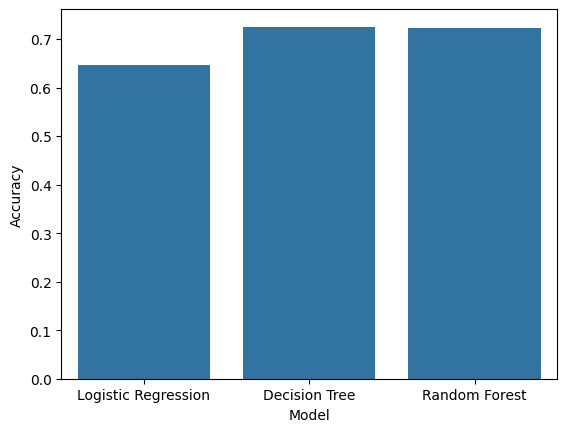

In [45]:
sns.barplot(x='Model', y='Accuracy', data=models)
plt.show()

In [46]:
print("\nFinal Comparison:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))


Final Comparison:
Logistic Regression: 0.6473333333333333
Decision Tree: 0.7253333333333334
Random Forest: 0.723


**Step 14-Conclusion**

In [ ]:
In this project, Logistic Regression, Decision Tree, and Random Forest models were implemented for Ad Click Prediction. Logistic Regression achieved 65% accuracy, Decision Tree achieved 72.53%, and Random Forest achieved 72.3% accuracy. Although Decision Tree showed slightly higher accuracy, Random Forest is considered more reliable and robust as it reduces overfitting and improves generalization. Therefore, Random Forest is selected as the best model for Ad Click Prediction.